In [28]:
import joblib
import numpy as np
import pandas as pd
import optuna
X_train = joblib.load("../features/X_train.pkl")
X_val = joblib.load("../features/X_val.pkl")
X_test = joblib.load("../features/X_test.pkl")

y_train = joblib.load("../features/y_train.pkl")
y_val = joblib.load("../features/y_val.pkl")
y_test = joblib.load("../features/y_test.pkl")

print(X_train.shape)

(34515, 13)


In [29]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

np.isnan(X_train_full).sum()

np.int64(0)

In [30]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
def xgb_objective(trial):
    
    params = {
        "objective": "binary:logistic",
        "n_estimators": trial.suggest_int("n_estimators",500,1000),
        "max_depth": trial.suggest_int("max_depth",6,12),
        "learning_rate": trial.suggest_float("learning_rate",0.1,0.3),
        "subsample": trial.suggest_float("subsample",0.8,1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.8,1.0),
        "gamma": trial.suggest_float("gamma",0,2),
        "min_child_weight": trial.suggest_int("min_child_weight",1,5),
        "scale_pos_weight": len(y_train_full[y_train_full == 0]) / len(y_train_full[y_train_full == 1]),
        "eval_metric": "auc",
        "n_jobs": -1,
        "random_state": 42
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    # Standard XGBoost model, no custom wrappers needed
    model = XGBClassifier(**params)
    
    # Manual Cross-Validation Loop
    for train_idx, val_idx in cv.split(X_train_full, y_train_full):
        # Depending on if your data is a Pandas DataFrame or Numpy Array:
        # Use .iloc if it's a DataFrame, or just [] if it's a NumPy array
        X_tr, X_val = X_train_full[train_idx], X_train_full[val_idx]
        y_tr, y_val = y_train_full[train_idx], y_train_full[val_idx]
        
        model.fit(X_tr, y_tr)
        
        # Get probabilities for the positive class (class 1)
        val_preds = model.predict_proba(X_val)[:, 1]
        
        # Calculate and store ROC-AUC directly
        score = roc_auc_score(y_val, val_preds)
        scores.append(score)
        
    return np.mean(scores)

In [32]:
study_xgb = optuna.create_study(direction="maximize")

study_xgb.optimize(xgb_objective, n_trials=100)

[I 2026-04-27 22:20:40,916] A new study created in memory with name: no-name-ba3105c1-7a07-4b9b-8d4a-63877f6bf198
[I 2026-04-27 22:20:46,051] Trial 0 finished with value: 0.9960567010827017 and parameters: {'n_estimators': 950, 'max_depth': 6, 'learning_rate': 0.23939650425108186, 'subsample': 0.8584038692515454, 'colsample_bytree': 0.8351000408139981, 'gamma': 1.28299067936291, 'min_child_weight': 2}. Best is trial 0 with value: 0.9960567010827017.
[I 2026-04-27 22:20:51,290] Trial 1 finished with value: 0.995326129857134 and parameters: {'n_estimators': 682, 'max_depth': 9, 'learning_rate': 0.22634802948982063, 'subsample': 0.8167006100371309, 'colsample_bytree': 0.9703589704293658, 'gamma': 0.476589114616927, 'min_child_weight': 2}. Best is trial 0 with value: 0.9960567010827017.
[I 2026-04-27 22:20:54,196] Trial 2 finished with value: 0.9960949865199092 and parameters: {'n_estimators': 503, 'max_depth': 12, 'learning_rate': 0.21024608823841956, 'subsample': 0.9100918043552068, 'col

In [47]:
print(study_xgb.best_params)
print(study_xgb.best_value)

{'n_estimators': 708, 'max_depth': 8, 'learning_rate': 0.13160165529917167, 'subsample': 0.904117506316051, 'colsample_bytree': 0.9487504480001521, 'gamma': 0.7969475567885541, 'min_child_weight': 5}
0.9963635265963511


In [48]:
best_xgb = XGBClassifier(
    **study_xgb.best_params
)

best_xgb.fit(X_train_full,y_train_full)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9487504480001521
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [35]:
val_probs = best_xgb.predict_proba(X_val)[:,1]

In [49]:
thresholds = np.linspace(0.05,0.95,50)

results = []

for t in thresholds:
    
    preds = (val_probs >= t).astype(int)
    
    accuracy = accuracy_score(y_val, preds)
    precision = precision_score(y_val,preds)
    recall = recall_score(y_val,preds)
    f1 = f1_score(y_val,preds)
    
    results.append((t, accuracy, precision, recall, f1))

results = np.array(results)


c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\SAMADRITA KARMAKAR\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


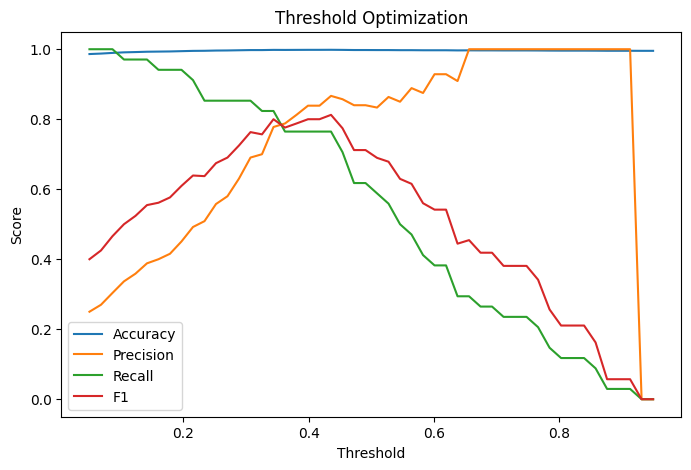

In [50]:
plt.figure(figsize=(8,5))

plt.plot(results[:,0],results[:,1],label="Accuracy")
plt.plot(results[:,0],results[:,2],label="Precision")
plt.plot(results[:,0],results[:,3],label="Recall")
plt.plot(results[:,0],results[:,4],label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization")
plt.legend()

plt.show()


In [51]:
best_index = np.argmin(np.abs(results[:,1] - 0.92))
best_threshold = results[best_index,0]

print("Best Threshold for 92% Accuracy:", best_threshold)
print("Accuracy:", results[best_index,1])
print("Precision:", results[best_index,2])
print("Recall:", results[best_index,3])
print("F1:", results[best_index,4])


Best Threshold for 92% Accuracy: 0.05
Accuracy: 0.9862087614926988
Precision: 0.25
Recall: 1.0
F1: 0.4


In [52]:
best_threshold = float(best_threshold)

val_preds = (val_probs >= best_threshold).astype(int)

In [53]:
print("Accuracy:", accuracy_score(y_val,val_preds))
print("Precision:", precision_score(y_val,val_preds))
print("Recall:", recall_score(y_val,val_preds))
print("F1:", f1_score(y_val,val_preds))
print("ROC-AUC:", roc_auc_score(y_val,val_probs))


Accuracy: 0.9862087614926988
Precision: 0.25
Recall: 1.0
F1: 0.4
ROC-AUC: 0.998833437205363


In [54]:
print(classification_report(y_val,val_preds))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      7362
           1       0.25      1.00      0.40        34

    accuracy                           0.99      7396
   macro avg       0.62      0.99      0.70      7396
weighted avg       1.00      0.99      0.99      7396



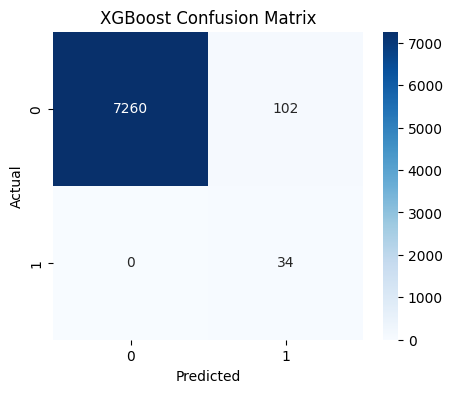

In [55]:
cm = confusion_matrix(y_val,val_preds)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")

plt.show()

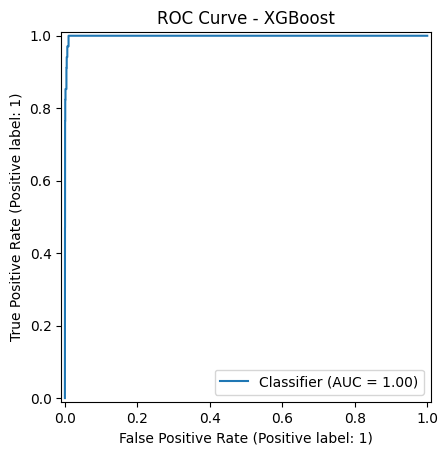

In [56]:
RocCurveDisplay.from_predictions(
    y_val,
    val_probs
)

plt.title("ROC Curve - XGBoost")

plt.show()

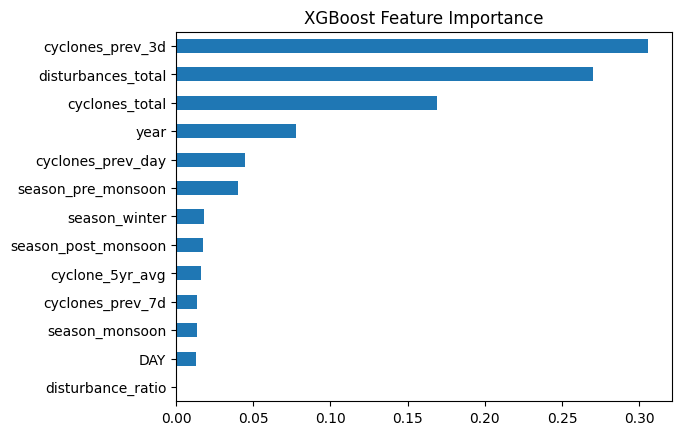

In [57]:
feature_names = X_train.columns.tolist()

importances = pd.Series(
    best_xgb.feature_importances_,
    index=feature_names
)

importances.sort_values().plot.barh()

plt.title("XGBoost Feature Importance")

plt.show()

In [58]:
test_preds = best_xgb.predict(X_test)
test_probs = best_xgb.predict_proba(X_test)[:,1]

print("TEST ROC-AUC:", roc_auc_score(y_test, test_probs))
print("TEST F1:", f1_score(y_test, test_preds))

TEST ROC-AUC: 0.9928444225116398
TEST F1: 0.3448275862068966


In [59]:
joblib.dump(
    best_xgb,
    "../models/xgb_optuna_model.pkl"
)

['../models/xgb_optuna_model.pkl']